<a href="https://colab.research.google.com/github/2d-game-dev/ComputerVisionProject/blob/main/Copy_of_INTRUSIONCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ce2bdqFeT7e9MGJbnEPa")
project = rf.workspace("my-workspace-y2ace").project("cctv-naxyo-drk6y")
dataset = project.version(1).download("yolov5")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 57.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13
loading Roboflow workspace...
loading Roboflow project...


Extracting Dataset Version Zip to cctv-1 in yolov5pytorch:: 100%|██████████| 7479/7479 [00:02<00:00, 3491.57it/s]


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import os
import numpy as np

from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from tqdm import tqdm

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")


Using device: cuda


In [4]:
class GridDataset(Dataset):

    def __init__(self, images_path, labels_path, grid_size=7):

        self.images = []
        self.labels = []
        self.grid_size = grid_size

        img_files = [
            f for f in os.listdir(images_path)
            if f.endswith(('.jpg', '.png'))
        ]

        print(f"📂 Loading {len(img_files)} images from {images_path}...")

        for img_file in img_files:

            label_file = (
                img_file.replace('.jpg', '.txt')
                .replace('.png', '.txt')
            )

            label_path = os.path.join(labels_path, label_file)

            grid = np.zeros((grid_size, grid_size, 5))

            if os.path.exists(label_path):

                with open(label_path, 'r') as f:

                    for line in f.readlines():

                        parts = line.strip().split()

                        if len(parts) == 5:

                            _, x, y, w, h = map(float, parts)

                            gx = int(x * grid_size)
                            gy = int(y * grid_size)

                            if gx < grid_size and gy < grid_size:

                                grid[gy, gx] = [1, x, y, w, h]

            self.images.append(
                os.path.join(images_path, img_file)
            )

            self.labels.append(grid)

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        img = Image.open(
            self.images[idx]
        ).convert('RGB')

        img = img.resize((224, 224))

        img = np.array(img) / 255.0

        img = torch.FloatTensor(img).permute(2, 0, 1)

        label = torch.FloatTensor(self.labels[idx])

        return img, label

In [5]:
class GridDetectionModel(nn.Module):

    def __init__(self, grid_size=7, dropout_rate=0.3):

        super().__init__()

        self.grid_size = grid_size

        self.features = nn.Sequential(

            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Dropout2d(dropout_rate)
        )

        self.fc = nn.Sequential(

            nn.Linear(128 * 14 * 14, 1024),

            nn.ReLU(),

            nn.Dropout(dropout_rate)
        )

        self.output = nn.Linear(
            1024,
            grid_size * grid_size * 5
        )

    def forward(self, x):

        x = self.features(x)

        x = x.view(x.size(0), -1)

        x = self.fc(x)

        x = self.output(x)

        x = x.view(-1, self.grid_size, self.grid_size, 5)

        x[..., 0] = torch.sigmoid(x[..., 0])

        x[..., 1:] = torch.sigmoid(x[..., 1:])

        return x


model = GridDetectionModel(
    dropout_rate=0.3
).to(device)


In [6]:
def detection_loss(pred, target):

    obj_mask = target[..., 0] > 0

    loss_conf = (
        (pred[..., 0] - target[..., 0]) ** 2
    ).mean()

    if obj_mask.sum() > 0:

        loss_bbox = (
            (
                pred[obj_mask][..., 1:]
                - target[obj_mask][..., 1:]
            ) ** 2
        ).mean()

    else:

        loss_bbox = 0

    return loss_conf + loss_bbox

In [7]:
dataset_path = "/content/cctv-1"

train_dataset = GridDataset(
    f"{dataset_path}/train/images",
    f"{dataset_path}/train/labels"
)

val_dataset = GridDataset(
    f"{dataset_path}/valid/images",
    f"{dataset_path}/valid/labels"
)

test_dataset = GridDataset(
    f"{dataset_path}/test/images",
    f"{dataset_path}/test/labels"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16
)


print("\n📊 DATASET SUMMARY")
print("---------------------------")
print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))


📂 Loading 3060 images from /content/cctv-1/train/images...
📂 Loading 526 images from /content/cctv-1/valid/images...
📂 Loading 151 images from /content/cctv-1/test/images...

📊 DATASET SUMMARY
---------------------------
Train images: 3060
Validation images: 526
Test images: 151


In [8]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 15

train_losses = []
val_losses = []

best_val_loss = float('inf')

for epoch in range(epochs):

    #Train
    model.train()

    total_train_loss = 0

    for images, targets in tqdm(train_loader):

        images = images.to(device)
        targets = targets.to(device)

        preds = model(images)

        loss = detection_loss(preds, targets)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = (
        total_train_loss / len(train_loader)
    )

    train_losses.append(avg_train_loss)

    #Validation
    model.eval()

    total_val_loss = 0

    with torch.no_grad():

        for images, targets in val_loader:

            images = images.to(device)
            targets = targets.to(device)

            preds = model(images)

            loss = detection_loss(preds, targets)

            total_val_loss += loss.item()

    avg_val_loss = (
        total_val_loss / len(val_loader)
    )

    val_losses.append(avg_val_loss)

    #Save best model
    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

        print("✅ Best model saved!")

    print(
        f"Epoch {epoch+1}: "
        f"Train Loss = {avg_train_loss:.4f} | "
        f"Validation Loss = {avg_val_loss:.4f}"
    )


100%|██████████| 192/192 [01:08<00:00,  2.79it/s]


✅ Best model saved!
Epoch 1: Train Loss = 0.0745 | Validation Loss = 0.0598


100%|██████████| 192/192 [01:08<00:00,  2.82it/s]


✅ Best model saved!
Epoch 2: Train Loss = 0.0644 | Validation Loss = 0.0549


100%|██████████| 192/192 [01:07<00:00,  2.84it/s]


...

Epoch 13: Train Loss = 0.0205 | Validation Loss = 0.0431


100%|██████████| 192/192 [01:03<00:00,  3.00it/s]


Epoch 14: Train Loss = 0.0190 | Validation Loss = 0.0433


100%|██████████| 192/192 [01:03<00:00,  3.03it/s]


Epoch 15: Train Loss = 0.0177 | Validation Loss = 0.0432


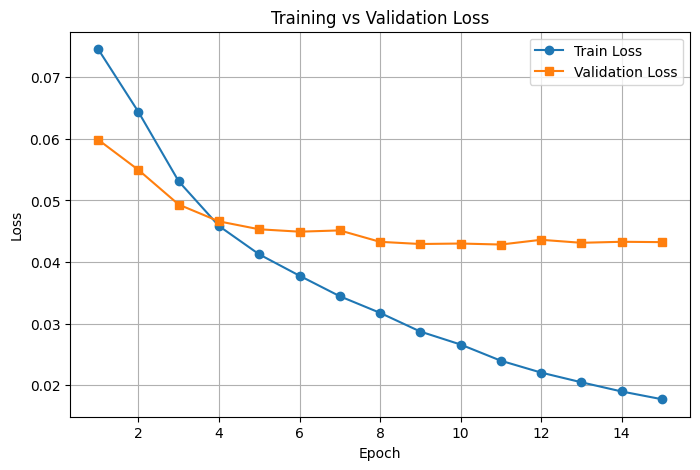


✅ Loaded best model for testing


In [20]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, epochs+1),
    train_losses,
    marker='o',
    label="Train Loss"
)

plt.plot(
    range(1, epochs+1),
    val_losses,
    marker='s',
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid()

plt.show()


# Load best model
model.load_state_dict(
    torch.load("best_model.pth")
)

print("\n✅ Loaded best model for testing")

model.eval();



In [17]:
def check_intrusion_from_grid(
    grid,
    restricted_zone=[0.3,0.4,0.7,0.6],
    threshold=0.12
):

    for i in range(grid.shape[0]):

        for j in range(grid.shape[1]):

            conf = grid[i,j,0]

            if conf > threshold:

                x, y, w, h = grid[i,j,1:]

                x1 = x - w/2
                y1 = y - h/2
                x2 = x + w/2
                y2 = y + h/2

                zx1, zy1, zx2, zy2 = restricted_zone

                if (
                    x1 < zx2 and
                    x2 > zx1 and
                    y1 < zy2 and
                    y2 > zy1
                ):
                    return True

    return False


# Person detection accuracy
person_correct = 0
person_total = 0

with torch.no_grad():

    for images, targets in test_loader:

        images = images.to(device)
        targets = targets.to(device)

        preds = model(images)

        pred_has_person = (
            preds[..., 0].amax(dim=(1,2)) > 0.12
        )

        true_has_person = (
            targets[..., 0].amax(dim=(1,2)) > 0.0
        )

        person_correct += (
            pred_has_person == true_has_person
        ).sum().item()

        person_total += targets.size(0)

person_accuracy = (
    100 * person_correct / person_total
)

print(
    f"\n📊 Person Detection Accuracy: "
    f"{person_accuracy:.1f}%"
)


#Overall intrusion detection accuracy
intrusion_correct = 0
intrusion_total = 0

with torch.no_grad():

    for images, targets in test_loader:

        images = images.to(device)

        preds = model(images).cpu().numpy()

        targets = targets.numpy()

        for pred, target in zip(preds, targets):


            pred_intrusion = check_intrusion_from_grid(
                pred,
                threshold=0.15
            )


            true_intrusion = check_intrusion_from_grid(
                target,
                threshold=0.0
            )


            if pred_intrusion == true_intrusion:

                intrusion_correct += 1

            intrusion_total += 1

intrusion_accuracy = (
    100 * intrusion_correct / intrusion_total
)

print(
    f"\n🚨 Overall Intrusion Detection Accuracy: "
    f"{intrusion_accuracy:.1f}%"
)


def detect_intrusion(
    model,
    image_path,
    restricted_zone=[0.28,0.38,0.72,0.62],
    threshold=0.15
):

    model.eval()

    img = Image.open(image_path).convert('RGB')

    img_resized = img.resize((224,224))

    img_tensor = torch.FloatTensor(
        np.array(img_resized) / 255.0
    ).permute(2,0,1).unsqueeze(0).to(device)

    with torch.no_grad():

        pred = model(img_tensor)[0].cpu().numpy()

    print("Max confidence:", pred[...,0].max())

    intrusion = False

    boxes = []

    for i in range(pred.shape[0]):

        for j in range(pred.shape[1]):

            conf = pred[i,j,0]

            if conf > threshold:

                x, y, w, h = pred[i,j,1:]

                boxes.append((x,y,w,h))

                x1 = x - w/2
                y1 = y - h/2
                x2 = x + w/2
                y2 = y + h/2

                zx1, zy1, zx2, zy2 = restricted_zone

                if (
                    x1 < zx2 and
                    x2 > zx1 and
                    y1 < zy2 and
                    y2 > zy1
                ):
                    intrusion = True


    fig, ax = plt.subplots(1)

    ax.imshow(img)

    h_img, w_img = img.size[1], img.size[0]

    # Restricted zone
    rz = patches.Rectangle(

        (
            restricted_zone[0] * w_img,
            restricted_zone[1] * h_img
        ),

        (
            restricted_zone[2]
            - restricted_zone[0]
        ) * w_img,

        (
            restricted_zone[3]
            - restricted_zone[1]
        ) * h_img,

        edgecolor='red',
        facecolor='red',
        alpha=0.3
    )

    ax.add_patch(rz)

    # Bounding boxes
    for (x,y,w,h) in boxes:

        rect = patches.Rectangle(

            (
                (x-w/2) * w_img,
                (y-h/2) * h_img
            ),

            w * w_img,
            h * h_img,

            edgecolor='yellow',
            facecolor='none'
        )

        ax.add_patch(rect)

    if intrusion:

        plt.title("INTRUSION DETECTED")

    else:

        plt.title("SAFE ZONE")

    plt.axis('off')

    plt.show()

    return intrusion






📊 Person Detection Accuracy: 98.0%

🚨 Overall Intrusion Detection Accuracy: 80.1%


Max confidence: 0.97304744


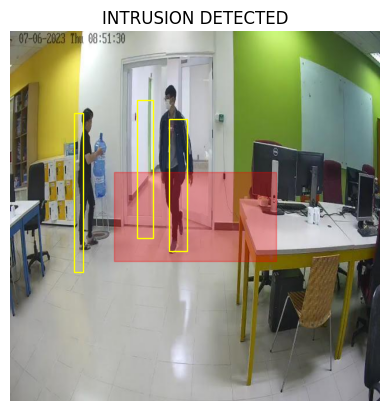

True

In [18]:
#Test single image
test_image = val_dataset.images[0]

detect_intrusion(model, test_image)



Frame 1
Max confidence: 0.97304744


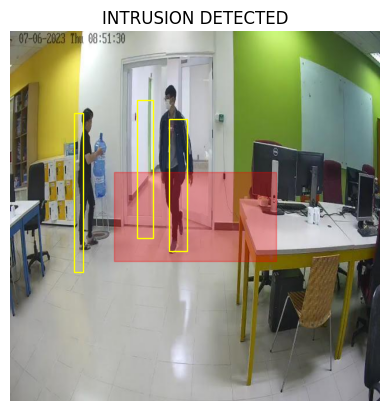


Frame 2
Max confidence: 0.9017501


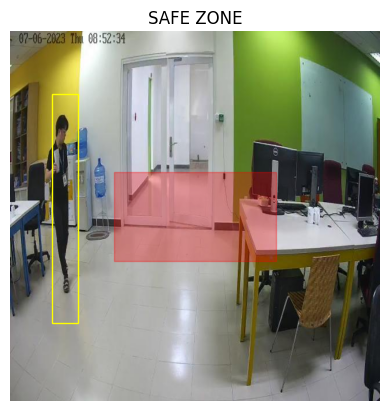


Frame 3
Max confidence: 0.24430525


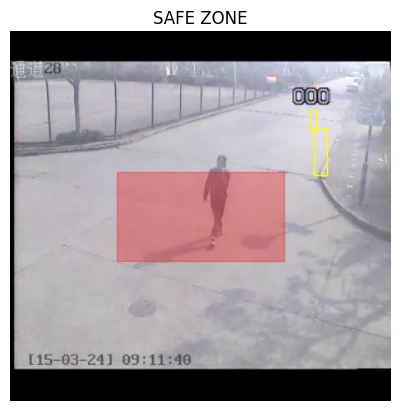


Frame 4
Max confidence: 0.97264254


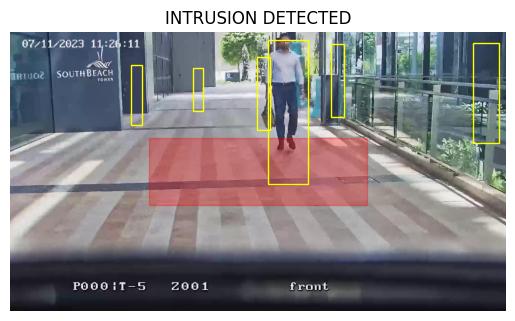


Frame 5
Max confidence: 0.57813513


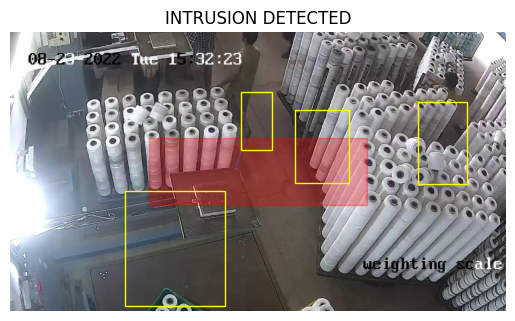


Frame 6
Max confidence: 0.7707842


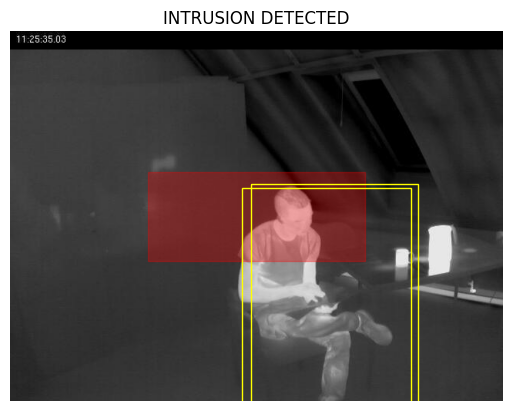


Frame 7
Max confidence: 0.33235988


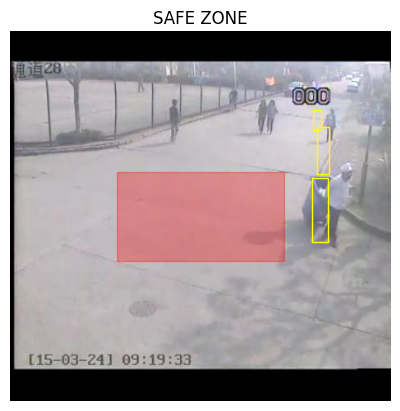


Frame 8
Max confidence: 0.07491148


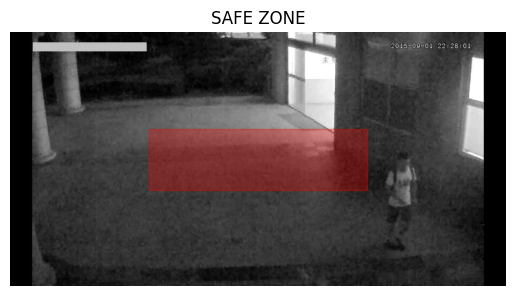


Frame 9
Max confidence: 0.80089843


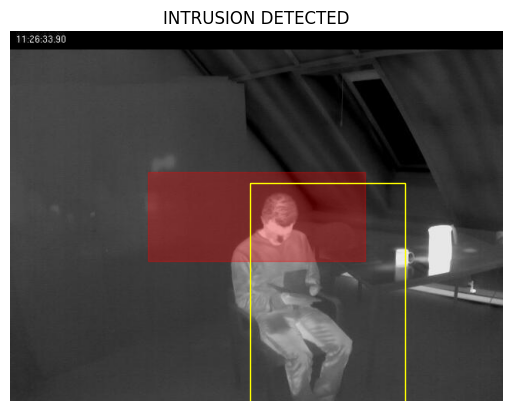


Frame 10
Max confidence: 0.53094774


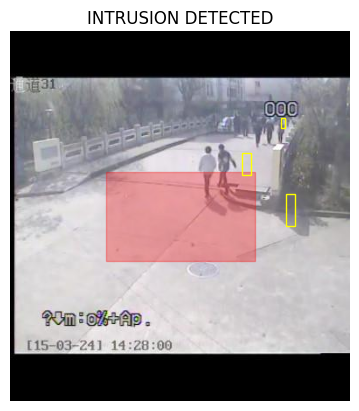

In [19]:
def simulate_cctv(model, folder, delay=1):

    images = os.listdir(folder)

    for i, img in enumerate(images[:10]):

        print(f"\nFrame {i+1}")

        detect_intrusion(
            model,
            os.path.join(folder, img)
        )

        plt.pause(delay)


simulate_cctv(
    model,
    os.path.dirname(val_dataset.images[0])
)